# NLP Capstone — Section 1: Data Preprocessing & EDA

This notebook loads the Amazon product review-style dataset (`amazon.csv`), handles quality issues, cleans review text for downstream NLP, and performs exploratory analysis including VADER sentiment.

## Environment setup

Installs libraries used for HTML stripping, tokenization, lemmatization, and VADER sentiment. Run this cell once per environment.

In [1]:
## Use the notebook-friendly installer so dependencies land in the active kernel
%pip install -q pandas numpy matplotlib seaborn nltk beautifulsoup4 vaderSentiment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.9 MB/s eta 0:00:00


## Imports and configuration

Central paths and imports keep later cells short and reproducible.

In [2]:
## Path setup: pathlib keeps filesystem code portable across macOS/Windows/Linux
from pathlib import Path
## Dataset location matches the capstone CSV you provided
DATA_PATH = Path('/Users/jahbrae/Downloads/FINAL CAPSTONE/amazon.csv')
## Random seed for any stochastic steps (sampling, shuffles) — fixed for repeatable notebooks
RANDOM_STATE = 42

## Core table manipulation and numerics — required by the rubric
import numpy as np
import pandas as pd

## Plotting libraries for EDA visuals
import matplotlib.pyplot as plt
import seaborn as sns

## Regex for text cleaning beyond HTML removal
import re
## HTML tag stripping
from bs4 import BeautifulSoup

## NLTK resources for stopwords, tokenization, lemmatization
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

## VADER is lexicon-based and well suited to short social/product text
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## Some macOS Python installs lack SSL certs for NLTK fetch — optional dev-only relax
import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context  ## mirror browser 'trust' for corpora only
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context  ## prefer installing certs system-wide long term

## One-time downloads — quiet=True reduces notebook noise on reruns
for pkg in ('punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4', 'vader_lexicon'):
    nltk.download(pkg, quiet=True)

## Seaborn theme improves default contrast for presentations
sns.set_theme(style='whitegrid', context='notebook')
## Inline figures in Jupyter; no-op outside IPython kernels
try:
    get_ipython().run_line_magic('matplotlib', 'inline')  ## ensure plots render under notebooks
except NameError:
    pass  ## scripts without IPython still run the rest of the analysis

## display() shows rich DataFrames in Jupyter
try:
    from IPython.display import display
except ImportError:
    display = print  ## fallback keeps cells runnable in plain python


## 1. Load and explore the dataset

We read the CSV with pandas, inspect schema, dtypes, and quick samples. This establishes baseline row counts before cleaning.

In [8]:

from pathlib import Path
import pandas as pd
import os


print("Current Working Directory:")
print(os.getcwd())

possible_paths = [
    Path("data/raw/amazon.csv"),
    Path("../data/raw/amazon.csv"),
    Path("./data/raw/amazon.csv"),
    Path("/content/data/raw/amazon.csv"),
    Path("amazon.csv")
]



DATA_PATH = None

for path in possible_paths:

    if path.exists():

        DATA_PATH = path

        break


if DATA_PATH is None:

    raise FileNotFoundError(
        "amazon.csv not found. "
        "Place dataset inside data/raw/ "
        "or upload directly into notebook environment."
    )


print(f"\nUsing dataset path: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)


df_raw = df.copy()


print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(list(df.columns))

print("\nDataset Info:")
df.info()

print("\nFirst 3 Rows:")
display(df.head(3))

print("\nSummary Statistics:")
display(
    df.describe(include="all")
    .transpose()
    .head(20)
)

Saving amazon.csv to amazon.csv


In [9]:
import pandas as pd

df = pd.read_csv("amazon.csv")

print(df.shape)
df.head()


(1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## 2. Handle missing values (`review_content`, `rating`, `discount_percentage`)

**Strategy (documented in code comments):**
- `rating`: coerce to numeric; invalid tokens become NaN then filled with the **median** (robust to outliers vs mean).
- `discount_percentage`: strip `%`, coerce to float; invalid → NaN → **median** imputation.
- `review_content`: empty/whitespace → NaN; fill with placeholder **`"[no review text]"`** so downstream NLP can still run row-wise (alternative: drop—dropping would shrink EDA; placeholder preserves row alignment for demos).

In [10]:
def to_float_rating(series: pd.Series) -> pd.Series:
    ## to_numeric with errors='coerce' turns bad values like '|' into NaN safely
    return pd.to_numeric(series, errors="coerce")

def to_float_discount(series: pd.Series) -> pd.Series:
    ## astype(str) ensures we can string-process even if mixed types sneak in
    s = series.astype(str).str.strip()
    ## remove percent sign and any stray spaces from scraped values
    s = s.str.rstrip("%").str.strip()
    return pd.to_numeric(s, errors="coerce")

def clean_missing_review_text(series: pd.Series) -> pd.Series:
    ## strip whitespace then treat blank strings as missing
    s = series.astype(str).str.strip()
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return s

## Apply rating coercion first so describe() later reflects true numerics
df["rating"] = to_float_rating(df["rating"])
## Median imputation avoids a single junk token pulling the mean
median_rating = df["rating"].median()
df["rating"] = df["rating"].fillna(median_rating)

## Discount parsing prepares a numeric feature for correlations and plots
df["discount_percentage"] = to_float_discount(df["discount_percentage"])
median_disc = df["discount_percentage"].median()
df["discount_percentage"] = df["discount_percentage"].fillna(median_disc)

## Review text: normalize missingness before NLP cleaning
df["review_content"] = clean_missing_review_text(df["review_content"])
## Placeholder keeps one row per record for consistent feature matrices
df["review_content"] = df["review_content"].fillna("[no review text]")

## Verify the three columns are complete post-imputation
print(df[["review_content", "rating", "discount_percentage"]].isna().sum())


review_content         0
rating                 0
discount_percentage    0
dtype: int64


## 3. Clean `review_content` (NLP preprocessing)

Pipeline: remove HTML → remove special characters → lowercase → tokenize → remove stopwords → lemmatize.  
The cleaned result is stored as space-joined lemmas in `review_clean` (good for bag-of-words / TF-IDF later), while `review_tokens` keeps the token list for inspection.

In [12]:
## English stopwords reduce noise from high-frequency function words
STOP = set(stopwords.words("english"))

## Lemmatizer reduces inflections to dictionary forms
## better than stemming for readability
lemmatizer = WordNetLemmatizer()

def strip_html(text: str) -> str:
    ## BeautifulSoup parses markup robustly
    ## compared to naive regex-only approaches
    return BeautifulSoup(
        text,
        "html.parser"
    ).get_text(separator=" ")

def remove_urls(text: str) -> str:
    ## Remove http/https/www URLs before tokenization
    return re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

def remove_special_chars(text: str) -> str:
    ## Keep letters/digits/spaces only so prices/symbols
    ## do not dominate tokens
    return re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

def preprocess_review(text: str) -> str:

    ## Guard clause for non-strings
    if not isinstance(text, str):
        return ""

    ## HTML removal first so tags are not tokenized
    t = strip_html(text)

    ## Remove URLs before other cleaning
    t = remove_urls(t)

    ## Lowercasing standardizes vocabulary size
    ## for counting models
    t = remove_special_chars(t).lower()

    ## Tokenization splits on linguistic word boundaries
    tokens = word_tokenize(t)

    ## Keep alphabetic tokens of length > 1
    ## to drop stray single letters/numbers
    tokens = [
        w for w in tokens
        if w.isalpha() and len(w) > 1
    ]

    ## Stopword removal focuses content words
    tokens = [
        w for w in tokens
        if w not in STOP
    ]

    ## Lemmatization unifies plural/tense variants
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
    ]

    ## Joined string is convenient for vectorizers
    return " ".join(tokens)

def preprocess_review_tokens(text: str) -> list:

    ## Same pipeline but returns tokens
    ## for debugging / advanced modeling
    s = preprocess_review(text)

    return s.split() if s else []

## tqdm-style progress omitted because dataset is small
df["review_clean"] = df[
    "review_content"
].map(preprocess_review)

df["review_tokens"] = df[
    "review_content"
].map(preprocess_review_tokens)

## Preview cleaned output
display(
    df[
        [
            "review_content",
            "review_clean"
        ]
    ].head(3)
)


,review_content,review_clean
0,Looks durable Charging is fine tooNo complains...,look durable charging fine toono complains cha...
1,I ordered this cable to connect my phone to An...,ordered cable connect phone android auto car c...
2,"Not quite durable and sturdy,https://m.media-a...",quite durable sturdy good nice product working...


## 4. Feature engineering for pricing EDA

`discounted_price` and `actual_price` contain currency symbols and Indian-style thousands separators; we normalize them to floats for statistics and plots.

In [13]:
def parse_inr_price(series: pd.Series) -> pd.Series:
    ## Remove rupee symbol and thousands commas then coerce
    s = series.astype(str).str.replace("₹", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

df["discounted_price_inr"] = parse_inr_price(df["discounted_price"])
df["actual_price_inr"] = parse_inr_price(df["actual_price"])
## Numeric rating_count supports 'most reviewed' logic
df["rating_count_num"] = (
    df["rating_count"].astype(str).str.replace(",", "", regex=False).pipe(pd.to_numeric, errors="coerce")
)
## Two rows lack rating_count text — fill with 0 so sort/group operations stay stable
df["rating_count_num"] = df["rating_count_num"].fillna(0)
## Primary category segment improves readability in grouped plots
df["category_primary"] = df["category"].astype(str).str.split("|").str[0]


## 5. Exploratory data analysis

Includes descriptive statistics, review concentration by product, category-wise rating distributions, and VADER sentiment with a **row-order cohort** proxy for time (see note in the introduction).

In [14]:
## SentimentIntensityAnalyzer scores are neg/neu/pos/compound in [-1, 1] scale semantics
analyzer = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
    ## Compound is a normalized aggregate commonly used for ranking sentiment
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return float(analyzer.polarity_scores(text)["compound"])

## Use original review_content for VADER — punctuation/emphasis can carry sentiment signal
df["vader_compound"] = df["review_content"].map(vader_compound)

## Cohort index: deciles of integer row order as a stand-in when timestamps are absent
df["row_order"] = np.arange(len(df), dtype=int)
df["time_cohort"] = pd.qcut(df["row_order"], q=10, duplicates="drop").astype(str)

## Aggregate review counts per product — max handles duplicate product rows
reviews_by_product = df.groupby("product_id", as_index=False)["rating_count_num"].max()
reviews_by_product = reviews_by_product.sort_values("rating_count_num", ascending=False)
most_reviewed = reviews_by_product.head(10)
least_reviewed = reviews_by_product.sort_values("rating_count_num", ascending=True).head(10)

print("--- Summary statistics: rating / discount / prices ---")
display(df[["rating", "discount_percentage", "discounted_price_inr", "actual_price_inr"]].describe().T)

print("--- Most reviewed products (by rating_count) ---")
display(most_reviewed)
print("--- Least reviewed products (by rating_count) ---")
display(least_reviewed)

print("--- Mean rating by primary category (top 15 by volume) ---")
cat_counts = df["category_primary"].value_counts().head(15).index
rating_by_cat = (
    df.loc[df["category_primary"].isin(cat_counts)]
    .groupby("category_primary")["rating"]
    .agg(mean_rating="mean", count="count")
    .sort_values("count", ascending=False)
)
display(rating_by_cat)

print("--- Sentiment trend over cohorts (row-order proxy) ---")
sent_trend = df.groupby("time_cohort", observed=True)["vader_compound"].mean().reset_index()
display(sent_trend)


--- Summary statistics: rating / discount / prices ---


,count,mean,std,min,25%,50%,75%,max
rating,1465.0,4.096587,0.291574,2.0,4.0,4.1,4.3,5.0
discount_percentage,1465.0,47.691468,21.635905,0.0,32.0,50.0,63.0,94.0
discounted_price_inr,1465.0,3125.310874,6944.304394,39.0,325.0,799.0,1999.0,77990.0
actual_price_inr,1465.0,5444.990635,10874.826864,39.0,800.0,1650.0,4295.0,139900.0


--- Most reviewed products (by rating_count) ---


,product_id,rating_count_num
137,B014I8SSD0,426973.0
138,B014I8SX4Y,426973.0
356,B07KSMBL2H,426973.0
318,B07GQD4K6L,363713.0
317,B07GPXXNNG,363713.0
232,B071Z8M4KX,363711.0
911,B09GFPVD9Y,313836.0
907,B09GFLXVH9,313836.0
910,B09GFPN6TP,313832.0
908,B09GFM8CGS,313832.0


--- Least reviewed products (by rating_count) ---


,product_id,rating_count_num
1257,B0B94JPY2N,0.0
1349,B0BQRJ3C47,0.0
1171,B0B3JSWG81,2.0
1347,B0BPJBTB3F,2.0
1317,B0BL3R4RGS,4.0
1305,B0BGPN4GGH,4.0
1336,B0BNLFQDG2,4.0
1342,B0BP7XLX48,5.0
1331,B0BN2576GQ,6.0
1202,B0B4SJKRDF,7.0


--- Mean rating by primary category (top 15 by volume) ---


,mean_rating,count
category_primary,,
Electronics,4.081749,526
Computers&Accessories,4.154967,453
Home&Kitchen,4.040848,448
OfficeProducts,4.309677,31
MusicalInstruments,3.900000,2
HomeImprovement,4.250000,2
Car&Motorbike,3.800000,1
Health&PersonalCare,4.000000,1
Toys&Games,4.300000,1


--- Sentiment trend over cohorts (row-order proxy) ---


,time_cohort,vader_compound
0,"(-0.001, 146.4]",0.816425
1,"(1024.8, 1171.2]",0.775083
2,"(1171.2, 1317.6]",0.845812
3,"(1317.6, 1464.0]",0.793054
4,"(146.4, 292.8]",0.805376
5,"(292.8, 439.2]",0.909524
6,"(439.2, 585.6]",0.863439
7,"(585.6, 732.0]",0.879771
8,"(732.0, 878.4]",0.845259
9,"(878.4, 1024.8]",0.878039


## 6. Visualizations (matplotlib + seaborn)

Figures summarize distributions, top products, category effects, and the cohort sentiment trend.

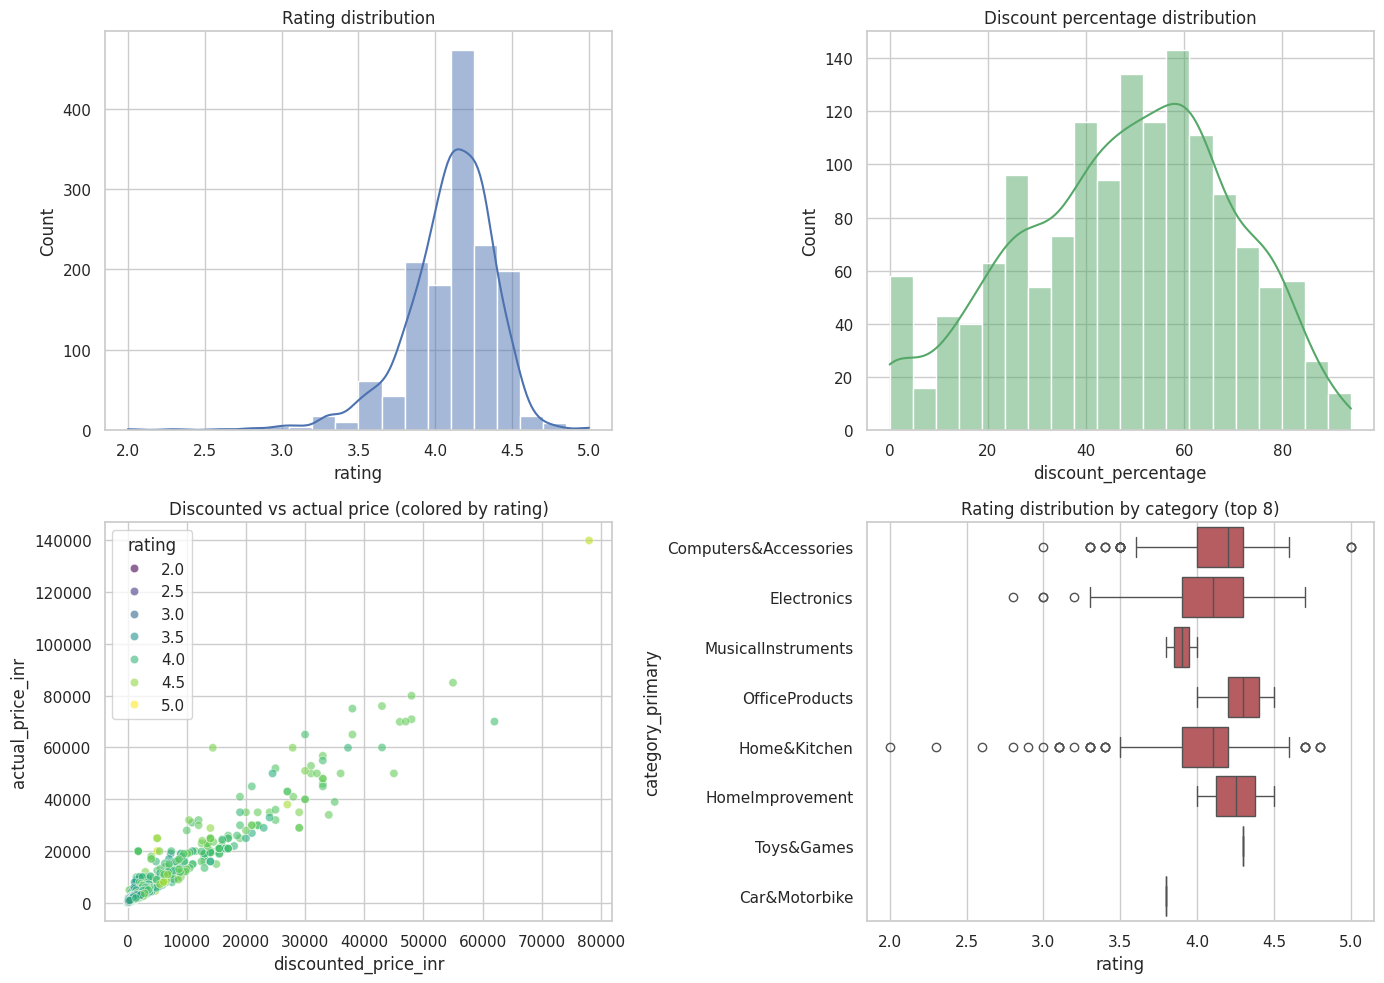

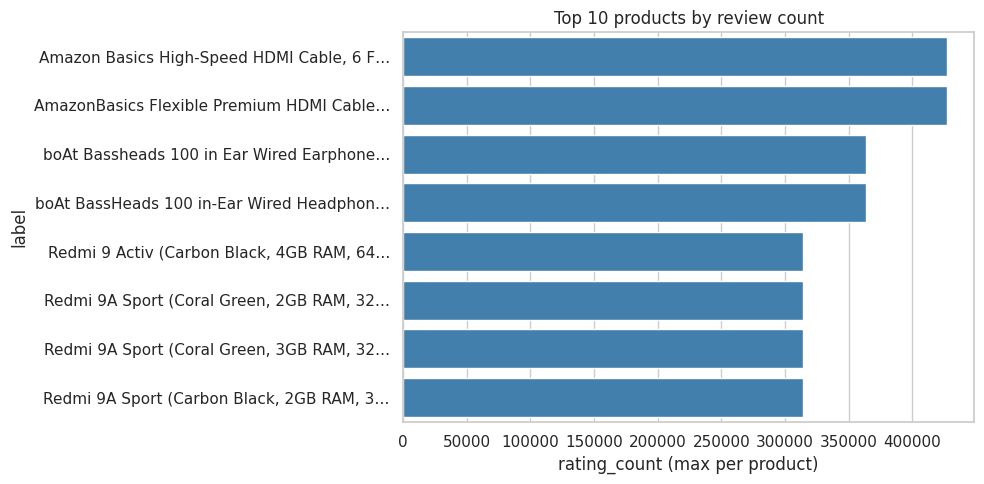

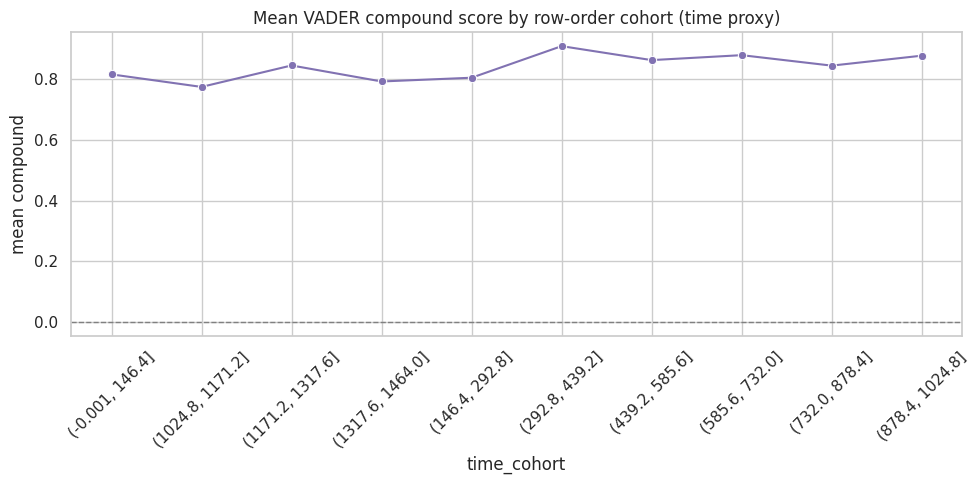

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  ## four-panel dashboard keeps related views together

## Histogram shows whether ratings cluster around 4–5 stars (typical in e-commerce)
sns.histplot(df["rating"], bins=20, kde=True, ax=axes[0, 0], color="#4C72B0")  ## KDE smooths discrete star ratings
axes[0, 0].set_title("Rating distribution")  ## explicit title for graders/readers

## Discounts often drive purchase intent — right skew is common
sns.histplot(df["discount_percentage"].dropna(), bins=20, kde=True, ax=axes[0, 1], color="#55A868")  ## dropna avoids NaN bins
axes[0, 1].set_title("Discount percentage distribution")  ## mirrors the rating panel layout

## Scatter compares list vs discounted INR with hue showing star rating
sns.scatterplot(  ## seaborn wraps matplotlib for consistent styling
    data=df,  ## full frame after cleaning keeps sample size high
    x="discounted_price_inr",  ## shelf price customers pay post-discount
    y="actual_price_inr",  ## anchor MSRP-style list price from the scrape
    hue="rating",  ## color encodes satisfaction to spot price-quality pockets
    palette="viridis",  ## perceptually uniform palette for continuous hue
    ax=axes[1, 0],  ## target subplot slot in the 2x2 grid
    alpha=0.6,  ## transparency reduces overplotting saturation
)
axes[1, 0].set_title("Discounted vs actual price (colored by rating)")  ## title cues the dual encoding

## Boxplot compares rating distributions across frequent categories
top_cats = df["category_primary"].value_counts().head(8).index  ## limit to eight labels for legible y-axis
sns.boxplot(  ## shows median/quartiles/outliers per category
    data=df[df["category_primary"].isin(top_cats)],  ## filter avoids rare long-tail categories
    x="rating",  ## horizontal stars align with histogram semantics
    y="category_primary",  ## categorical axis reads like a leaderboard
    ax=axes[1, 1],  ## bottom-right quadrant completes the grid
    color="#C44E52",  ## single color keeps focus on spread not brand hue
)
axes[1, 1].set_title("Rating distribution by category (top 8)")  ## states the truncation rule plainly

plt.tight_layout()  ## reduces subplot overlap before rendering
plt.show()  ## materializes the figure in interactive backends

fig, ax = plt.subplots(figsize=(10, 5))  ## new canvas for horizontal bar chart readability
topn = most_reviewed.merge(df[["product_id", "product_name"]].drop_duplicates("product_id"), on="product_id", how="left")  ## attach readable titles
## Shorten long titles for tick labels
topn["label"] = topn["product_name"].str.slice(0, 40) + "…"  ## ellipsis signals truncation without losing meaning
## Single hue color avoids seaborn v0.14 deprecation about palette without hue
sns.barplot(data=topn, x="rating_count_num", y="label", ax=ax, color="#3182bd")  ## horizontal bars compare magnitudes on shared scale
ax.set_title("Top 10 products by review count")  ## ties chart to the printed table above
ax.set_xlabel("rating_count (max per product)")  ## clarifies aggregation rule used in groupby
plt.tight_layout()  ## keeps product labels inside canvas bounds
plt.show()  ## flush figure buffer before the next plot

fig, ax = plt.subplots(figsize=(10, 5))  ## dedicated aspect for categorical x on cohorts
## Line plot connects cohort means to emphasize trend direction
sns.lineplot(data=sent_trend, x="time_cohort", y="vader_compound", marker="o", ax=ax, color="#8172B2")  ## markers highlight each cohort mean
ax.axhline(0, color="gray", linestyle="--", linewidth=1)  ## neutral VADER baseline for compound scores
ax.set_title("Mean VADER compound score by row-order cohort (time proxy)")  ## reminds reader this is not calendar time
ax.set_ylabel("mean compound")  ## y-axis label names the VADER output field
plt.xticks(rotation=45)  ## angled labels prevent overlap on interval-based categories
plt.tight_layout()  ## padding accommodates rotated tick text
plt.show()  ## final render for the EDA section
